In [5]:
import numpy as np
import matplotlib.pyplot as plt
##velocity profile between two plates

# ----------------------------
# Parameters
# ----------------------------
H = 1.0              # gap between plates
Ny = 21              # number of grid points

nu = 0.01            # kinematic viscosity
U0 = 1.0             # speed of the top plate

dy = H / (Ny - 1)
dt = 0.1             # time step
Nt = 1200            # number of time steps

y = np.linspace(0, H, Ny)

# Stability parameter for FTCS
r = nu * dt / dy**2
print("r =", r)

# FTCS is stable only if r <= 0.5
if r > 0.5:
    print("Warning: scheme may be unstable!")

# ----------------------------
# Initial condition
# ----------------------------
# fluid at rest everywhere
u = np.zeros(Ny)

# Boundary conditions: bottom plate fixed, top plate moving
u[0] = 0
u[-1] = U0

# Store solution for plotting
solution = [u.copy()]

# ----------------------------
# Time evolution
# ----------------------------
for n in range(Nt):
    u_new = u.copy()

    for i in range(1, Ny - 1):
        u_new[i] = u[i] + r * (u[i+1] - 2*u[i] + u[i-1])

    # fixed boundary conditions
    u_new[0] = 0
    u_new[-1] = U0

    u = u_new
    solution.append(u.copy())

solution = np.array(solution)
print("solution shape =", solution.shape)

# steady state for comparison
u_steady = U0 * y / H

# vorticity of the steady profile
omega = np.gradient(u_steady, y)
print("vorticity =", round(omega[Ny//2], 3), " expected U0/H =", U0/H)

r = 0.3999999999999999
solution shape = (1201, 21)
vorticity = 1.0  expected U0/H = 1.0


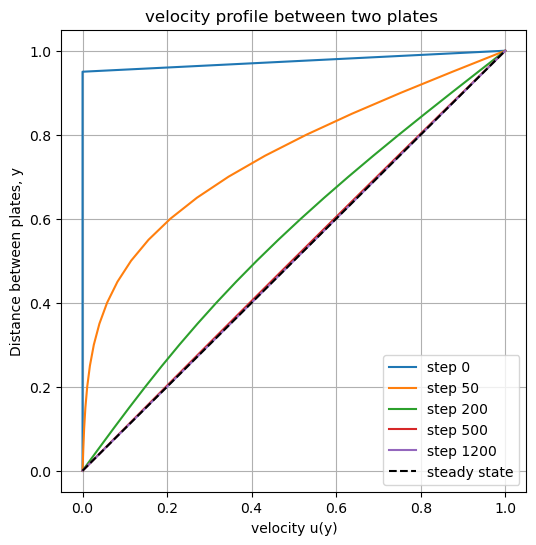

In [6]:
# ----------------------------
# Snapshots of the velocity profile
# ----------------------------
plt.figure(figsize=(6,6))
for n in [0, 50, 200, 500, 1200]:
    plt.plot(solution[n], y, label=f"step {n}")
plt.plot(u_steady, y, 'k--', label="steady state")
plt.xlabel("velocity u(y)")
plt.ylabel("Distance between plates, y")
plt.title("velocity profile between two plates ")
plt.legend()
plt.grid()
plt.show()
